# Causal Neuron Pruning on Car Evaluation

Self-contained Colab notebook.

**What's different**
1. ADF stationarity testing before Granger causality (missing in the base pipeline)
2. Neuron -> output causality (matches the ATCP papers), not neuron <-> neuron
3. Causal pruning benchmarked against magnitude and random baselines, across 3 seeds

See `README.md` in the project zip for the full writeup of why each of these matters.

In [3]:
import zipfile
import os

# Define the path to the zip file
zip_file_path = '/content/car-evaluation-causal-pruning_1.zip'

# Define the directory where you want to extract the contents
extract_dir = '/content/car-evaluation-causal-pruning'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f'Files extracted to: {extract_dir}')

# List the contents of the extracted directory to see the structure
print('\nContents of the extracted directory:')
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')

Files extracted to: /content/car-evaluation-causal-pruning

Contents of the extracted directory:
car-evaluation-causal-pruning/
    car-evaluation-causal-pruning/
        requirements.txt
        Car_Evaluation_Causal_Pruning.ipynb
        README.md
        run_experiment.py
        results/
            causality_seed42.csv
            summary_mean_std.csv
            causality_summary.csv
            combined_results.csv
            activations_seed42.csv
            models/
        src/
            model.py
            causality.py
            config.py
            trainer.py
            evaluation.py
            experiment.py
            visualization.py
            data.py
            __init__.py
            pruning.py
            __pycache__/
                evaluation.cpython-313.pyc
                pruning.cpython-313.pyc
                model.cpython-313.pyc
                trainer.cpython-313.pyc
                config.cpython-313.pyc
                data.cpython-313.pyc
     

## 1. Install dependencies

In [4]:
!pip install -q statsmodels scikit-learn scipy matplotlib pandas torch


## 2. Materialize the project source files

This writes out the exact `src/` package used in the pushable GitHub repo, so the notebook and the repo stay in sync.

In [5]:
import os
os.makedirs('src', exist_ok=True)
os.makedirs('results', exist_ok=True)
print('directories ready')


directories ready


In [6]:
%%writefile src/config.py
"""Global configuration for the Car Evaluation causal pruning study."""

import pathlib
import random

import numpy as np
import torch

# -- Reproducibility -------------------------------------------------------
SEEDS = [42, 123, 2024]   # multi-seed: the source papers use only seed=42;
                          # we report mean +/- std across 3 seeds for a
                          # genuine robustness claim they don't make.


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# -- Paths -------------------------------------------------------------------
ROOT     = pathlib.Path(__file__).parent.parent
RESULTS  = ROOT / "results"
MODELS   = RESULTS / "models"
RESULTS.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

# -- Data ----------------------------------------------------------------------
DATASET_NAME = "car"          # OpenML: car (Car Evaluation)
TEST_SIZE    = 0.2

# -- Model / training ----------------------------------------------------------
HIDDEN_DIMS      = [64, 32]
BATCH_SIZE       = 64
EPOCHS_BASELINE  = 40
EPOCHS_FINETUNE  = 15
LEARNING_RATE    = 1e-3

# -- Importance weighting -------------------------------------------------------
ALPHA = 0.4   # weight magnitude
BETA  = 0.3   # activation strength
GAMMA = 0.3   # causal significance (ADF-filtered Granger, neuron -> output)

# -- Pruning ---------------------------------------------------------------------
PRUNE_PERCENTAGES = [10, 20, 30, 40, 50, 60, 70]
METHODS = ["causal", "magnitude", "random"]   # causal = ours, other two = baselines

# -- Causality -----------------------------------------------------------------
GRANGER_MAX_LAG   = 5      # kept lower than the source papers' L=14 deliberately:
                            # with only ~64-neuron hidden layers and a few hundred
                            # logged steps, lag=14 starves the regression of degrees
                            # of freedom (T - 2L - 1 shrinks fast). We report this
                            # as a documented deviation, not a silent one.
GRANGER_SAMPLE    = 400    # activation steps logged for causality analysis
ADF_ALPHA         = 0.05   # stationarity significance threshold
GRANGER_ALPHA     = 0.05   # causality significance threshold


Writing src/config.py


In [7]:
%%writefile src/data.py
"""Car Evaluation dataset loading."""

from __future__ import annotations

import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset

from .config import BATCH_SIZE, TEST_SIZE


def load_car_evaluation():
    """Fetch Car Evaluation from OpenML and one-hot encode features.

    Returns (X_train, X_test, y_train, y_test, feature_names, class_names).
    """
    car = fetch_openml(name="car", version=3, parser="auto")
    X_df = pd.get_dummies(car.data)
    feature_names = list(X_df.columns)

    X = X_df.values.astype(np.float32)
    le = LabelEncoder()
    y = le.fit_transform(car.target).astype(np.int64)
    class_names = list(le.classes_)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test, feature_names, class_names


def get_car_loaders(batch_size: int = BATCH_SIZE, num_workers: int = 0):
    """Return (train_loader, test_loader, input_dim, output_dim, meta)."""
    X_train, X_test, y_train, y_test, feature_names, class_names = load_car_evaluation()

    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
    test_ds = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    meta = {
        "feature_names": feature_names,
        "class_names": class_names,
        "n_train": len(train_ds),
        "n_test": len(test_ds),
    }
    return train_loader, test_loader, X_train.shape[1], len(class_names), meta


Writing src/data.py


In [8]:
%%writefile src/model.py
"""MLP with structural (physically shrinking) pruning support."""

from __future__ import annotations

from typing import Optional

import torch
import torch.nn as nn


class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], output_dim: int) -> None:
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.output_dim = output_dim

        dims = [input_dim] + hidden_dims + [output_dim]
        layers: list[nn.Module] = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)

        self._hidden_layers = [m for m in self.net if isinstance(m, nn.Linear)][:-1]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x.view(x.size(0), -1))

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    @classmethod
    def from_dims(cls, input_dim: int, hidden_dims: list[int], output_dim: int) -> "MLP":
        return cls(input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim)

    def copy_weights_from(self, source: "MLP", keep_indices: list[Optional[list[int]]]) -> None:
        """Copy surviving-neuron weights from a larger source model."""
        src_linears = [m for m in source.net if isinstance(m, nn.Linear)]
        dst_linears = [m for m in self.net if isinstance(m, nn.Linear)]
        assert len(keep_indices) == len(src_linears) - 1

        with torch.no_grad():
            for i in range(len(src_linears)):
                src, dst = src_linears[i], dst_linears[i]
                out_idx = keep_indices[i] if i < len(keep_indices) else None
                in_idx = keep_indices[i - 1] if i > 0 else None

                W, b = src.weight.data, src.bias.data
                if out_idx is not None:
                    W, b = W[out_idx, :], b[out_idx]
                if in_idx is not None:
                    W = W[:, in_idx]
                dst.weight.data.copy_(W)
                dst.bias.data.copy_(b)


Writing src/model.py


In [9]:
%%writefile src/trainer.py
"""Training, evaluation, activation logging, inference timing."""

from __future__ import annotations

import time
from pathlib import Path
from typing import Optional

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from .config import LEARNING_RATE


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += logits.argmax(1).eq(y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            correct += logits.argmax(1).eq(y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total


def train(model, train_loader, test_loader, epochs, device, lr=LEARNING_RATE, verbose=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, test_loader, criterion, device)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        if verbose and (epoch % 5 == 0 or epoch == epochs):
            print(f"  epoch {epoch:3d}/{epochs}  train_acc={tr_acc:.4f}  val_acc={va_acc:.4f}")

    return history


class ActivationLogger:
    """Logs per-step hidden activations AND the true-class output logit,
    which is what causality.py needs to test neuron -> output influence
    (rather than neuron -> neuron, which the source repo measured)."""

    def __init__(self):
        self._hooks = []
        self._activations: dict[str, list[float]] = {}

    def register_hooks(self, model: nn.Module) -> None:
        linears = [m for m in model.net if isinstance(m, nn.Linear)]
        for idx, layer in enumerate(linears[:-1]):
            name = f"hidden_{idx}"
            h = layer.register_forward_hook(self._make_hook(name))
            self._hooks.append(h)

    def _make_hook(self, name: str):
        def hook(module, inp, out):
            self._activations[name] = out.detach().mean(0).cpu().tolist()
        return hook

    def remove(self):
        for h in self._hooks:
            h.remove()


def log_activations(model, loader, device, max_steps, csv_path: Path) -> pd.DataFrame:
    """Run a pass over `loader`, log mean hidden activations per step plus
    the mean predicted-probability of the true class (the "output" series
    used for neuron -> output Granger causality)."""
    model.eval()
    logger = ActivationLogger()
    logger.register_hooks(model)

    rows = []
    softmax = nn.Softmax(dim=1)
    with torch.no_grad():
        for step, (x, y) in enumerate(loader):
            if step >= max_steps:
                break
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = softmax(logits)
            true_class_prob = probs.gather(1, y.unsqueeze(1)).mean().item()

            row = {"step": step, "output_true_class_prob": true_class_prob}
            for name, acts in logger._activations.items():
                for i, v in enumerate(acts):
                    row[f"{name}_n{i}"] = v
            rows.append(row)

    logger.remove()
    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)
    return df


def measure_inference_time(model, loader, device, n_runs: int = 50) -> float:
    model.eval()
    batch = next(iter(loader))[0][:64].to(device)
    with torch.no_grad():
        for _ in range(5):
            model(batch)
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter()
            model(batch)
            times.append((time.perf_counter() - t0) * 1000)
    return float(torch.tensor(times).mean().item())


Writing src/trainer.py


In [10]:
%%writefile src/causality.py
"""Stationarity testing (ADF) + Granger causality of each hidden neuron
against the network's OUTPUT signal.

This is the core research improvement over the base repo:

1. The base repo never checks stationarity before running Granger
   causality. Granger causality on a non-stationary series is a textbook
   spurious-regression risk (the F-test can find "significant" causality
   between two series that share nothing but a trend). The ATCP papers this
   project builds on DO check this with an ADF test -- the base repo
   silently skipped it. We add it back, matching the source papers'
   rigor, and difference any non-stationary series once before testing
   (a standard remedy) rather than either ignoring the problem or
   discarding those neurons outright.

2. The base repo computed an N x N matrix of neuron <-> neuron causality
   and used "mean influence received from other neurons" as the causal
   score. That is a different quantity from what the ATCP papers actually
   define: whether a neuron's own activation history Granger-causes the
   OUTPUT. We compute that directly (neuron -> output), which is O(N)
   instead of O(N^2), so it is also cheap enough to run at the full lag
   the papers use if you want to push GRANGER_MAX_LAG back up to 14 for a
   direct comparison.
"""

from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import f as f_dist
from statsmodels.tsa.stattools import adfuller

from .config import ADF_ALPHA, GRANGER_ALPHA, GRANGER_MAX_LAG


def adf_stationarity(series: np.ndarray, alpha: float = ADF_ALPHA) -> tuple[bool, float, np.ndarray]:
    """Return (is_stationary, p_value, series_used).

    If the raw series is non-stationary, first-difference it once and
    re-test (standard remedy). If still non-stationary, flag it as such --
    the caller should down-weight/exclude that neuron's causal score
    rather than trusting a Granger test run on a non-stationary signal.
    """
    series = np.asarray(series, dtype=np.float64)
    if np.allclose(series, series[0]):
        # constant series (e.g. dead ReLU neuron) -- can't test, treat as
        # non-stationary/non-informative
        return False, 1.0, series

    try:
        _, pval, *_ = adfuller(series, autolag="AIC")
    except Exception:
        return False, 1.0, series

    if pval < alpha:
        return True, pval, series

    # try one differencing pass
    diff = np.diff(series)
    if len(diff) < 10 or np.allclose(diff, diff[0]):
        return False, pval, series
    try:
        _, pval_d, *_ = adfuller(diff, autolag="AIC")
    except Exception:
        return False, pval, series

    return (pval_d < alpha), pval_d, diff


def _ols_rss(y: np.ndarray, X: np.ndarray) -> float:
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ coef
    return float(resid @ resid)


def granger_f_test(x: np.ndarray, y: np.ndarray, max_lag: int) -> tuple[float, float]:
    """Does x Granger-cause y? Returns (F, p_value)."""
    T = len(y)
    if T <= 2 * max_lag + 2:
        return 0.0, 1.0
    try:
        Y = y[max_lag:]
        n = len(Y)
        Xr = np.column_stack([np.ones(n)] + [y[max_lag - k: T - k] for k in range(1, max_lag + 1)])
        Xu = np.column_stack([Xr] + [x[max_lag - k: T - k] for k in range(1, max_lag + 1)])

        rss_r = _ols_rss(Y, Xr)
        rss_u = _ols_rss(Y, Xu)
        if rss_u < 1e-12:
            return 0.0, 1.0

        df1, df2 = max_lag, n - Xu.shape[1]
        if df2 <= 0:
            return 0.0, 1.0

        F = max(((rss_r - rss_u) / df1) / (rss_u / df2), 0.0)
        p = float(f_dist.sf(F, df1, df2))
        return float(F), p
    except Exception:
        return 0.0, 1.0


def compute_neuron_output_causality(
    activations_csv: Path,
    max_lag: int = GRANGER_MAX_LAG,
    p_threshold: float = GRANGER_ALPHA,
    save_path: Path | None = None,
) -> pd.DataFrame:
    """For every hidden neuron, test ADF stationarity then Granger-causality
    against the output (true-class probability) series.

    Returns a DataFrame indexed by neuron name with columns:
    stationary, adf_pvalue, f_stat, granger_pvalue, is_causal
    """
    df = pd.read_csv(activations_csv)
    neuron_cols = [c for c in df.columns if c.startswith("hidden_")]
    output_series = df["output_true_class_prob"].values.astype(np.float64)

    rows = []
    for col in neuron_cols:
        series = df[col].values.astype(np.float64)
        stationary, adf_p, series_used = adf_stationarity(series)

        if not stationary:
            # non-stationary neuron: cannot trust a raw Granger F-test on it.
            # score as non-causal (p=1.0) rather than silently including it.
            rows.append({
                "neuron": col, "stationary": False, "adf_pvalue": adf_p,
                "f_stat": 0.0, "granger_pvalue": 1.0, "is_causal": False,
            })
            continue

        # align output series length to the (possibly differenced) neuron series
        out = output_series[-len(series_used):] if len(series_used) < len(output_series) else output_series
        n = min(len(series_used), len(out))
        f_stat, p_val = granger_f_test(series_used[:n], out[:n], max_lag)

        rows.append({
            "neuron": col, "stationary": True, "adf_pvalue": adf_p,
            "f_stat": f_stat, "granger_pvalue": p_val,
            "is_causal": p_val < p_threshold,
        })

    result = pd.DataFrame(rows).set_index("neuron")
    if save_path is not None:
        result.to_csv(save_path)
    return result


Writing src/causality.py


In [11]:
%%writefile src/pruning.py
"""Importance scoring and structural pruning for three methods:

  causal    -- our method (weight + activation + ADF-filtered Granger causality)
  magnitude -- classic weight-magnitude baseline (Hagiwara-style, used in the
               survey paper you're building on; also what the ATCP papers
               never actually benchmarked against)
  random    -- random baseline, the sanity-check floor: if causal doesn't
               clearly beat random, the causality signal isn't adding value.

Including magnitude + random directly answers the #1 limitation the ATCP
paper states about itself: "has not been directly compared with established
pruning techniques ... under identical experimental settings."
"""

from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from .config import ALPHA, BETA, GAMMA
from .model import MLP


def _minmax(arr: np.ndarray) -> np.ndarray:
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-8)


def compute_causal_importance(
    model: MLP,
    activations_csv: Path,
    causality_df: pd.DataFrame,
    alpha: float = ALPHA,
    beta: float = BETA,
    gamma: float = GAMMA,
) -> dict[str, np.ndarray]:
    act_df = pd.read_csv(activations_csv)
    linears = [m for m in model.net if isinstance(m, nn.Linear)][:-1]

    importance: dict[str, np.ndarray] = {}
    for layer_idx, linear in enumerate(linears):
        name = f"hidden_{layer_idx}"

        W = linear.weight.data.cpu().numpy()
        w_mag = np.abs(W).mean(axis=1)

        act_cols = [c for c in act_df.columns if c.startswith(f"{name}_n")]
        act_mean = np.abs(act_df[act_cols].values).mean(axis=0)

        # causal score: -log10(p) for causal neurons (bigger = more
        # significant), 0 for non-causal / non-stationary neurons
        layer_neurons = [c for c in causality_df.index if c.startswith(f"{name}_n")]
        c_score = np.zeros(len(w_mag))
        for i, col in enumerate(layer_neurons):
            if i >= len(c_score):
                break
            row = causality_df.loc[col]
            if row["is_causal"]:
                c_score[i] = -np.log10(max(row["granger_pvalue"], 1e-12))

        n = min(len(w_mag), len(act_mean), len(c_score))
        w_mag, act_mean, c_score = w_mag[:n], act_mean[:n], c_score[:n]

        score = alpha * _minmax(w_mag) + beta * _minmax(act_mean) + gamma * _minmax(c_score)
        importance[name] = score

    return importance


def compute_magnitude_importance(model: MLP) -> dict[str, np.ndarray]:
    """Baseline: importance = mean |weight| only."""
    linears = [m for m in model.net if isinstance(m, nn.Linear)][:-1]
    importance = {}
    for layer_idx, linear in enumerate(linears):
        W = linear.weight.data.cpu().numpy()
        importance[f"hidden_{layer_idx}"] = np.abs(W).mean(axis=1)
    return importance


def compute_random_importance(model: MLP, rng: np.random.Generator) -> dict[str, np.ndarray]:
    """Baseline: random importance scores (sanity-check floor)."""
    linears = [m for m in model.net if isinstance(m, nn.Linear)][:-1]
    importance = {}
    for layer_idx, linear in enumerate(linears):
        importance[f"hidden_{layer_idx}"] = rng.random(linear.out_features)
    return importance


def prune_model(model: MLP, prune_pct: float, importance: dict[str, np.ndarray]) -> tuple[MLP, list[list[int]]]:
    """Structurally rebuild a smaller model keeping the top-scoring neurons."""
    if prune_pct == 0:
        keep_indices = [list(range(len(v))) for v in importance.values()]
        return model, keep_indices

    keep_indices: list[list[int]] = []
    for scores in importance.values():
        n_total = len(scores)
        n_remove = int(n_total * prune_pct / 100)
        n_keep = max(1, n_total - n_remove)
        ranked = np.argsort(scores)[::-1]
        keep_indices.append(sorted(ranked[:n_keep].tolist()))

    new_hidden_dims = [len(ki) for ki in keep_indices]
    new_model = MLP.from_dims(model.input_dim, new_hidden_dims, model.output_dim)
    new_model.copy_weights_from(model, keep_indices)
    return new_model, keep_indices


Writing src/pruning.py


In [12]:
%%writefile src/evaluation.py
"""Evaluation: accuracy, F1, size, inference time."""

from __future__ import annotations

import os
import tempfile

import torch
import torch.nn as nn
from sklearn.metrics import f1_score

from .trainer import evaluate, measure_inference_time


def get_model_size_kb(model: nn.Module) -> float:
    with tempfile.NamedTemporaryFile(suffix=".pt", delete=False) as f:
        path = f.name
    torch.save(model.state_dict(), path)
    size_kb = os.path.getsize(path) / 1024
    os.unlink(path)
    return size_kb


def evaluate_full(model, test_loader, device, label, method, seed, prune_pct, train_loss=0.0) -> dict:
    criterion = nn.CrossEntropyLoss()
    test_loss, acc = evaluate(model, test_loader, criterion, device)

    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(y.cpu().numpy())
    f1 = f1_score(labels, preds, average="macro")

    return {
        "label": label,
        "method": method,
        "seed": seed,
        "prune_pct": prune_pct,
        "train_loss": round(train_loss, 4),
        "test_loss": round(test_loss, 4),
        "accuracy": round(acc, 4),
        "f1_score": round(f1, 4),
        "n_params": sum(p.numel() for p in model.parameters() if p.requires_grad),
        "model_size_kb": round(get_model_size_kb(model), 2),
        "inference_ms": round(measure_inference_time(model, test_loader, device), 3),
    }


Writing src/evaluation.py


In [13]:
%%writefile src/experiment.py
"""Runs the full comparison: causal vs magnitude vs random pruning,
across multiple seeds and pruning percentages, on Car Evaluation.

This is the actual research deliverable: a single combined_results.csv
with every (seed, method, prune_pct) combination, from which the
mean +/- std comparison plot and table are built.
"""

from __future__ import annotations

import copy

import numpy as np
import pandas as pd
import torch

from . import config as cfg
from .causality import compute_neuron_output_causality
from .data import get_car_loaders
from .evaluation import evaluate_full
from .model import MLP
from .pruning import (
    compute_causal_importance,
    compute_magnitude_importance,
    compute_random_importance,
    prune_model,
)
from .trainer import log_activations, train


def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def run_all(
    seeds: list[int] = cfg.SEEDS,
    prune_pcts: list[int] = cfg.PRUNE_PERCENTAGES,
    methods: list[str] = cfg.METHODS,
    epochs_baseline: int = cfg.EPOCHS_BASELINE,
    epochs_finetune: int = cfg.EPOCHS_FINETUNE,
) -> pd.DataFrame:
    device = get_device()
    all_rows: list[dict] = []
    causality_summaries: list[dict] = []

    for seed in seeds:
        print(f"\n{'='*70}\nSEED {seed}\n{'='*70}")
        cfg.set_seed(seed)

        train_loader, test_loader, input_dim, output_dim, meta = get_car_loaders()

        # -- baseline training ---------------------------------------------
        model = MLP(input_dim=input_dim, hidden_dims=cfg.HIDDEN_DIMS, output_dim=output_dim).to(device)
        history = train(model, train_loader, test_loader, epochs_baseline, device, verbose=True)

        baseline_row = evaluate_full(
            model, test_loader, device, label="baseline", method="baseline",
            seed=seed, prune_pct=0, train_loss=history["train_loss"][-1],
        )
        all_rows.append(baseline_row)
        print(f"  baseline: acc={baseline_row['accuracy']:.4f}  params={baseline_row['n_params']}")

        # -- activation logging + causality (once per seed, reused by the
        #    'causal' method across all prune_pcts) --------------------------
        act_csv = cfg.RESULTS / f"activations_seed{seed}.csv"
        log_activations(model, train_loader, device, cfg.GRANGER_SAMPLE, act_csv)

        causality_csv = cfg.RESULTS / f"causality_seed{seed}.csv"
        causality_df = compute_neuron_output_causality(
            act_csv, max_lag=cfg.GRANGER_MAX_LAG, save_path=causality_csv
        )
        n_causal = int(causality_df["is_causal"].sum())
        n_stationary = int(causality_df["stationary"].sum())
        n_total = len(causality_df)
        print(f"  causality: {n_stationary}/{n_total} neurons stationary, "
              f"{n_causal}/{n_total} Granger-cause the output (p<{cfg.GRANGER_ALPHA})")
        causality_summaries.append({
            "seed": seed, "n_neurons": n_total,
            "n_stationary": n_stationary, "n_causal": n_causal,
        })

        rng = np.random.default_rng(seed)

        # -- prune + fine-tune, per method, per pruning level -----------------
        for method in methods:
            for pct in prune_pcts:
                model_copy = copy.deepcopy(model)

                if method == "causal":
                    importance = compute_causal_importance(model_copy, act_csv, causality_df)
                elif method == "magnitude":
                    importance = compute_magnitude_importance(model_copy)
                elif method == "random":
                    importance = compute_random_importance(model_copy, rng)
                else:
                    raise ValueError(method)

                pruned_model, keep_idx = prune_model(model_copy, pct, importance)
                pruned_model.to(device)

                pruned_history = train(pruned_model, train_loader, test_loader, epochs_finetune, device)

                row = evaluate_full(
                    pruned_model, test_loader, device,
                    label=f"{method}_{pct}", method=method, seed=seed, prune_pct=pct,
                    train_loss=pruned_history["train_loss"][-1],
                )
                all_rows.append(row)
                print(f"  {method:10s} {pct:3d}%  acc={row['accuracy']:.4f}  "
                      f"params={row['n_params']:5d}  inf={row['inference_ms']:.2f}ms")

    results_df = pd.DataFrame(all_rows)
    results_df.to_csv(cfg.RESULTS / "combined_results.csv", index=False)

    pd.DataFrame(causality_summaries).to_csv(cfg.RESULTS / "causality_summary.csv", index=False)

    summary = (
        results_df[results_df["method"] != "baseline"]
        .groupby(["method", "prune_pct"])
        .agg(
            accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
            f1_mean=("f1_score", "mean"), f1_std=("f1_score", "std"),
            params_mean=("n_params", "mean"),
            inference_ms_mean=("inference_ms", "mean"),
        )
        .reset_index()
    )
    summary.to_csv(cfg.RESULTS / "summary_mean_std.csv", index=False)

    print(f"\nSaved: {cfg.RESULTS / 'combined_results.csv'}")
    print(f"Saved: {cfg.RESULTS / 'summary_mean_std.csv'}")
    return results_df


Writing src/experiment.py


In [22]:
%%writefile src/experiment.py
"""Runs the full comparison: causal vs magnitude vs random pruning,
across multiple seeds and pruning percentages, on Car Evaluation.

This is the actual research deliverable: a single combined_results.csv
with every (seed, method, prune_pct) combination, from which the
mean +/- std comparison plot and table are built.
"""

from __future__ import annotations

import copy

import numpy as np
import pandas as pd
import torch

from . import config as cfg
from .causality import compute_neuron_output_causality
from .data import get_car_loaders
from .evaluation import evaluate_full
from .model import MLP
from .pruning import (
    compute_causal_importance,
    compute_magnitude_importance,
    compute_random_importance,
    prune_model,
)
from .trainer import log_activations, train


def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def run_all(
    seeds: list[int] = cfg.SEEDS,
    prune_pcts: list[int] = cfg.PRUNE_PERCENTAGES,
    methods: list[str] = cfg.METHODS,
    epochs_baseline: int = cfg.EPOCHS_BASELINE,
    epochs_finetune: int = cfg.EPOCHS_FINETUNE,
) -> pd.DataFrame:
    device = get_device()
    all_rows: list[dict] = []
    causality_summaries: list[dict] = []

    for seed in seeds:
        print(f"\n{'='*70}\nSEED {seed}\n{'='*70}")
        cfg.set_seed(seed)

        train_loader, test_loader, input_dim, output_dim, meta = get_car_loaders()

        # -- baseline training ---------------------------------------------
        model = MLP(input_dim=input_dim, hidden_dims=cfg.HIDDEN_DIMS, output_dim=output_dim).to(device)
        history = train(model, train_loader, test_loader, epochs_baseline, device, verbose=True)

        baseline_row = evaluate_full(
            model, test_loader, device, label="baseline", method="baseline",
            seed=seed, prune_pct=0, train_loss=history["train_loss"][-1],
        )
        all_rows.append(baseline_row)
        print(f"  baseline: acc={baseline_row['accuracy']:.4f}  params={baseline_row['n_params']}")

        # --- Add this line to save the baseline model ---
        torch.save(model.state_dict(), cfg.MODELS / f'baseline_seed{seed}.pt')
        # -------------------------------------------------

        # -- activation logging + causality (once per seed, reused by the
        #    'causal' method across all prune_pcts) --------------------------
        act_csv = cfg.RESULTS / f"activations_seed{seed}.csv"
        log_activations(model, train_loader, device, cfg.GRANGER_SAMPLE, act_csv)

        causality_csv = cfg.RESULTS / f"causality_seed{seed}.csv"
        causality_df = compute_neuron_output_causality(
            act_csv, max_lag=cfg.GRANGER_MAX_LAG, save_path=causality_csv
        )
        n_causal = int(causality_df["is_causal"].sum())
        n_stationary = int(causality_df["stationary"].sum())
        n_total = len(causality_df)
        print(f"  causality: {n_stationary}/{n_total} neurons stationary, "
              f"{n_causal}/{n_total} Granger-cause the output (p<{cfg.GRANGER_ALPHA})")
        causality_summaries.append({
            "seed": seed, "n_neurons": n_total,
            "n_stationary": n_stationary, "n_causal": n_causal,
        })

        rng = np.random.default_rng(seed)

        # -- prune + fine-tune, per method, per pruning level -----------------
        for method in methods:
            for pct in prune_pcts:
                model_copy = copy.deepcopy(model)

                if method == "causal":
                    importance = compute_causal_importance(model_copy, act_csv, causality_df)
                elif method == "magnitude":
                    importance = compute_magnitude_importance(model_copy)
                elif method == "random":
                    importance = compute_random_importance(model_copy, rng)
                else:
                    raise ValueError(method)

                pruned_model, keep_idx = prune_model(model_copy, pct, importance)
                pruned_model.to(device)

                pruned_history = train(pruned_model, train_loader, test_loader, epochs_finetune, device)

                row = evaluate_full(
                    pruned_model, test_loader, device,
                    label=f"{method}_{pct}", method=method, seed=seed, prune_pct=pct,
                    train_loss=pruned_history["train_loss"][-1],
                )
                all_rows.append(row)
                print(f"  {method:10s} {pct:3d}%  acc={row['accuracy']:.4f}  "
                      f"params={row['n_params']:5d}  inf={row['inference_ms']:.2f}ms")

    results_df = pd.DataFrame(all_rows)
    results_df.to_csv(cfg.RESULTS / "combined_results.csv", index=False)

    pd.DataFrame(causality_summaries).to_csv(cfg.RESULTS / "causality_summary.csv", index=False)

    summary = (
        results_df[results_df["method"] != "baseline"]
        .groupby(["method", "prune_pct"])
        .agg(
            accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
            f1_mean=("f1_score", "mean"), f1_std=("f1_score", "std"),
            params_mean=("n_params", "mean"),
            inference_ms_mean=("inference_ms", "mean"),
        )
        .reset_index()
    )
    summary.to_csv(cfg.RESULTS / "summary_mean_std.csv", index=False)

    print(f"\nSaved: {cfg.RESULTS / 'combined_results.csv'}")
    print(f"Saved: {cfg.RESULTS / 'summary_mean_std.csv'}")
    return results_df

Overwriting src/experiment.py


In [14]:
%%writefile src/visualization.py
"""Comparison plots: causal vs magnitude vs random, with error bars from
the multi-seed runs -- the plot the ATCP papers don't have."""

from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

METHOD_COLORS = {"causal": "#1D9E75", "magnitude": "#378ADD", "random": "#888780"}


def plot_method_comparison(summary_csv: Path, baseline_acc: float, save_path: Path) -> None:
    df = pd.read_csv(summary_csv)

    fig, ax = plt.subplots(figsize=(8, 5))
    for method in ["causal", "magnitude", "random"]:
        sub = df[df["method"] == method].sort_values("prune_pct")
        if sub.empty:
            continue
        ax.errorbar(
            sub["prune_pct"], sub["accuracy_mean"], yerr=sub["accuracy_std"],
            label=method, marker="o", capsize=3, color=METHOD_COLORS.get(method),
        )

    ax.axhline(baseline_acc, color="black", linestyle="--", linewidth=1, label="baseline (0% pruned)")
    ax.set_xlabel("Neurons pruned (%)")
    ax.set_ylabel("Test accuracy (mean +/- std across seeds)")
    ax.set_title("Car Evaluation: causal vs magnitude vs random pruning")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.close(fig)


def plot_causality_summary(causality_summary_csv: Path, save_path: Path) -> None:
    df = pd.read_csv(causality_summary_csv)
    fig, ax = plt.subplots(figsize=(7, 4))
    x = range(len(df))
    ax.bar(x, df["n_stationary"], label="stationary neurons", color="#5DCAA5", alpha=0.8)
    ax.bar(x, df["n_causal"], label="Granger-causal neurons", color="#0F6E56")
    ax.set_xticks(list(x))
    ax.set_xticklabels([f"seed {s}" for s in df["seed"]])
    ax.set_ylabel("Neuron count")
    ax.set_title("ADF stationarity + Granger causality per seed")
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.close(fig)


Writing src/visualization.py


In [15]:
%%writefile src/__init__.py
"""Car Evaluation causal pruning study - src package."""

from . import config
from .config import set_seed
from .data import get_car_loaders
from .model import MLP
from .trainer import train, log_activations, measure_inference_time
from .causality import adf_stationarity, granger_f_test, compute_neuron_output_causality
from .pruning import (
    compute_causal_importance,
    compute_magnitude_importance,
    compute_random_importance,
    prune_model,
)
from .evaluation import evaluate_full
from .experiment import run_all, get_device
from .visualization import plot_method_comparison, plot_causality_summary

__all__ = [
    "config", "set_seed",
    "get_car_loaders",
    "MLP",
    "train", "log_activations", "measure_inference_time",
    "adf_stationarity", "granger_f_test", "compute_neuron_output_causality",
    "compute_causal_importance", "compute_magnitude_importance", "compute_random_importance", "prune_model",
    "evaluate_full",
    "run_all", "get_device",
    "plot_method_comparison", "plot_causality_summary",
]


Writing src/__init__.py


## 3. Run the full experiment

This trains a baseline for each seed, logs activations, runs ADF + Granger causality, then prunes + fine-tunes for all three methods (causal / magnitude / random) at every pruning level. Takes a while -- grab a coffee. Use the faster smoke-test cell below first if you just want to check everything runs.

### Optional: fast smoke-test first (1 seed, 2 pruning levels, few epochs)

In [16]:
import sys
sys.path.insert(0, '/content/car-evaluation-causal-pruning/car-evaluation-causal-pruning/')
from src.experiment import run_all
from src.visualization import plot_method_comparison, plot_causality_summary
from src import config as cfg

# quick smoke test
results_df = run_all(seeds=[42], prune_pcts=[20, 50], methods=['causal', 'magnitude', 'random'],
                      epochs_baseline=15, epochs_finetune=5)
print(results_df.head(10))


SEED 42
  epoch   5/15  train_acc=0.7583  val_acc=0.7977
  epoch  10/15  train_acc=0.8857  val_acc=0.8699
  epoch  15/15  train_acc=0.9313  val_acc=0.9306
  baseline: acc=0.9306  params=3620
  causality: 78/96 neurons stationary, 5/96 Granger-cause the output (p<0.05)
  causal      20%  acc=0.9335  params= 2630  inf=0.12ms
  causal      50%  acc=0.9133  params= 1300  inf=0.28ms
  magnitude   20%  acc=0.9480  params= 2630  inf=0.33ms
  magnitude   50%  acc=0.9306  params= 1300  inf=0.33ms
  random      20%  acc=0.9422  params= 2630  inf=0.70ms
  random      50%  acc=0.8960  params= 1300  inf=0.26ms

Saved: /content/car-evaluation-causal-pruning/car-evaluation-causal-pruning/results/combined_results.csv
Saved: /content/car-evaluation-causal-pruning/car-evaluation-causal-pruning/results/summary_mean_std.csv
          label     method  seed  prune_pct  train_loss  test_loss  accuracy  \
0      baseline   baseline    42          0      0.1894     0.1841    0.9306   
1     causal_20     cau

### Full experiment (all 3 seeds x 3 methods x 7 pruning levels -- the real result)

In [23]:
import shutil
import os

# Define the base directory of the extracted project
project_root_dir = '/content/car-evaluation-causal-pruning/car-evaluation-causal-pruning'

# Ensure the models directory exists before running the experiment
models_dir = os.path.join(project_root_dir, 'results', 'models')
os.makedirs(models_dir, exist_ok=True)

# Now, run the experiment as usual
results_df = run_all()  # uses defaults from src/config.py: SEEDS, PRUNE_PERCENTAGES, METHODS
results_df.head(20)


SEED 42
  epoch   5/40  train_acc=0.7583  val_acc=0.7977
  epoch  10/40  train_acc=0.8857  val_acc=0.8699
  epoch  15/40  train_acc=0.9313  val_acc=0.9306
  epoch  20/40  train_acc=0.9595  val_acc=0.9480
  epoch  25/40  train_acc=0.9725  val_acc=0.9711
  epoch  30/40  train_acc=0.9812  val_acc=0.9884
  epoch  35/40  train_acc=0.9884  val_acc=0.9971
  epoch  40/40  train_acc=0.9949  val_acc=0.9942
  baseline: acc=0.9942  params=3620
  causality: 73/96 neurons stationary, 1/96 Granger-cause the output (p<0.05)
  causal      10%  acc=0.9942  params= 3107  inf=0.14ms
  causal      20%  acc=0.9942  params= 2630  inf=0.12ms
  causal      30%  acc=1.0000  params= 2144  inf=0.20ms
  causal      40%  acc=1.0000  params= 1742  inf=0.16ms
  causal      50%  acc=0.9855  params= 1300  inf=0.20ms
  causal      60%  acc=0.9769  params=  979  inf=0.13ms
  causal      70%  acc=0.9740  params=  694  inf=0.14ms
  magnitude   10%  acc=0.9971  params= 3107  inf=0.12ms
  magnitude   20%  acc=0.9971  params

,label,method,seed,prune_pct,train_loss,test_loss,accuracy,f1_score,n_params,model_size_kb,inference_ms
0,baseline,baseline,42,0,0.0362,0.0406,0.9942,0.9957,3620,17.25,0.128
1,causal_10,causal,42,10,0.0107,0.0199,0.9942,0.9957,3107,15.13,0.141
2,causal_20,causal,42,20,0.0128,0.0218,0.9942,0.9957,2630,13.25,0.125
3,causal_30,causal,42,30,0.0181,0.0235,1.0000,1.0000,2144,11.32,0.199
4,causal_40,causal,42,40,0.0324,0.0351,1.0000,1.0000,1742,9.82,0.157
5,causal_50,causal,42,50,0.0542,0.0587,0.9855,0.9893,1300,8.19,0.205
6,causal_60,causal,42,60,0.0881,0.0877,0.9769,0.9830,979,6.82,0.126
7,causal_70,causal,42,70,0.1445,0.1437,0.9740,0.9484,694,5.69,0.137
8,magnitude_10,magnitude,42,10,0.0087,0.0154,0.9971,0.9979,3107,15.13,0.115
9,magnitude_20,magnitude,42,20,0.0104,0.0175,0.9971,0.9979,2630,13.25,0.136


## 4. Build comparison plots and summary tables

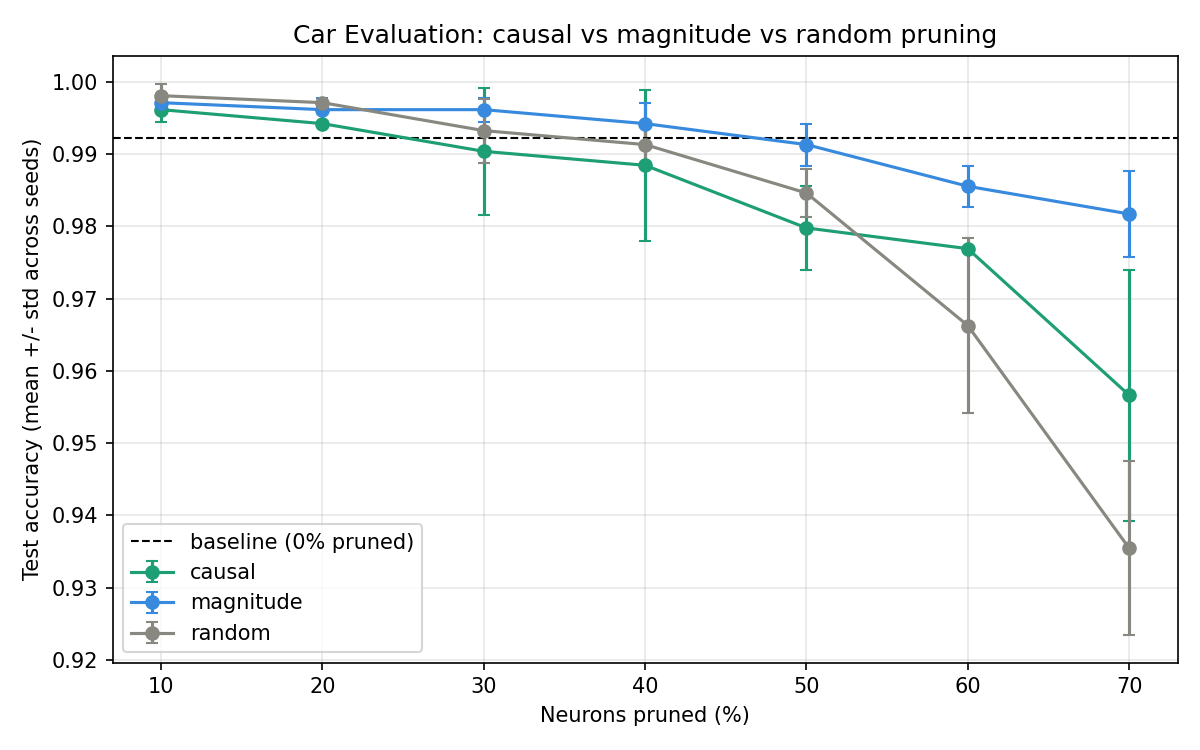

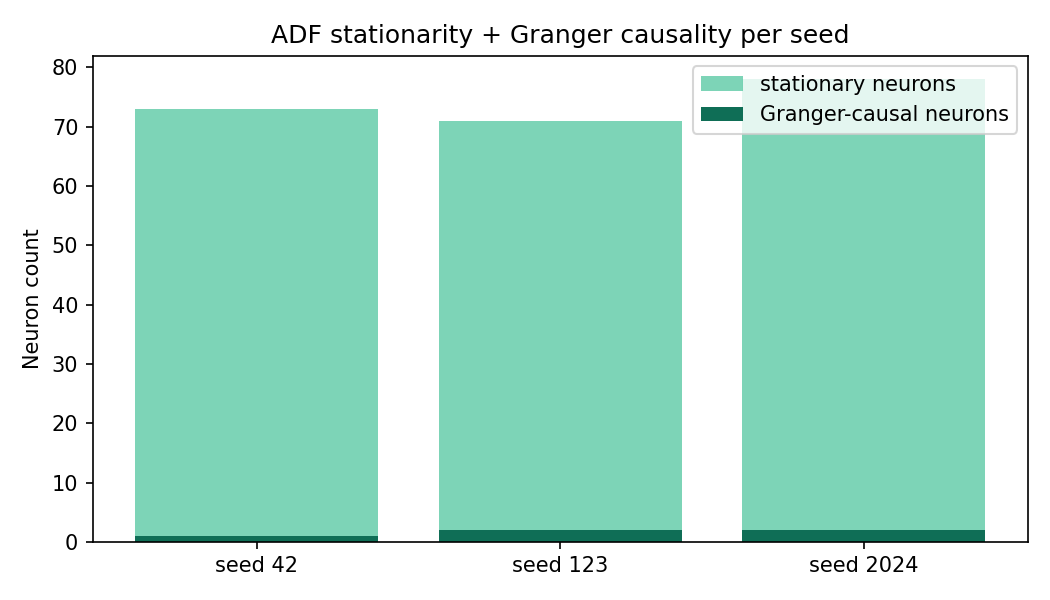

In [18]:
baseline_acc = results_df[results_df['method'] == 'baseline']['accuracy'].mean()

plot_method_comparison(cfg.RESULTS / 'summary_mean_std.csv', baseline_acc, cfg.RESULTS / 'method_comparison.png')
plot_causality_summary(cfg.RESULTS / 'causality_summary.csv', cfg.RESULTS / 'causality_summary.png')

from IPython.display import Image, display
display(Image(str(cfg.RESULTS / 'method_comparison.png')))
display(Image(str(cfg.RESULTS / 'causality_summary.png')))


## 5. Summary table for the slide deck

In [19]:
import pandas as pd
summary = pd.read_csv(cfg.RESULTS / 'summary_mean_std.csv')
summary.sort_values(['method', 'prune_pct'])


,method,prune_pct,accuracy_mean,accuracy_std,f1_mean,f1_std,params_mean,inference_ms_mean
0,causal,10,0.996133,0.001674,0.997167,0.001270,3107.0,0.152667
1,causal,20,0.994200,0.000000,0.992800,0.005110,2630.0,0.286000
2,causal,30,0.990367,0.008816,0.984500,0.014936,2144.0,0.212667
3,causal,40,0.988433,0.010415,0.982867,0.016120,1742.0,0.298000
4,causal,50,0.979767,0.005750,0.968200,0.021150,1300.0,0.169000
5,causal,60,0.976900,0.000000,0.971533,0.009935,979.0,0.216667
6,causal,70,0.956633,0.017350,0.859567,0.087388,694.0,0.124000
7,magnitude,10,0.997100,0.000000,0.997900,0.000000,3107.0,0.148000
8,magnitude,20,0.996133,0.001674,0.994233,0.006351,2630.0,0.116000
9,magnitude,30,0.996133,0.001674,0.994233,0.006351,2144.0,0.115667


## 6. Download results

Zips everything in `results/` so you can pull it out of Colab and hand it to your team for the slides.

In [24]:
import shutil
from google.colab import files

# Define the base directory of the extracted project to be archived
project_root_to_archive = '/content/car-evaluation-causal-pruning/car-evaluation-causal-pruning'

# Create the archive of the entire project directory
shutil.make_archive('car_eval_causal_pruning_project', 'zip', root_dir=project_root_to_archive)

files.download('car_eval_causal_pruning_project.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>